# HCMUT EE MACHINE LEARNING & IOT
## BTVN Buổi 2: Đại số tuyến tính cho AI

Môn học: Python & Machine Learning

Sinh viên: Nguyễn Bá Quốc Long

MSSV: 2550137


### Lựa chọn dữ liệu

Tôi lựa chọn text (tiếng Việt) và chỉ sử dụng thư viện Numpy và Matplotlib cho cả hai bài

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Bài 1 - Biểu diễn dữ liệu thành ma trận & độ tương đồng

#### Biến dữ liệu thành ma trận

In [2]:
cau = [
    "Trí tuệ nhân tạo AI là công nghệ thay đổi cách làm việc mỗi ngày",
    "Học máy là công nghệ giúp máy tính tự học từ dữ liệu thực tế",
    "Mô hình ngôn ngữ lớn là công nghệ AI hiểu văn bản như con người",
    "Mạng neural nhân tạo mô phỏng bộ não trong công nghệ máy tính",

    "Cấu trúc dữ liệu giải thuật là kỹ năng cốt lõi của sinh viên",
    "Tôi cố gắng học tập tối ưu để sinh viên đạt kết quả tốt hơn",
    "Luyện tập giải thuật giúp sinh viên rèn luyện kỹ năng tư duy",
    "Cân bằng học tập và câu lạc bộ giúp sinh viên phát triển kỹ năng",

    "Cơm tấm là món ăn ẩm thực đặc sản nổi tiếng tại Sài Gòn",
    "Một ly cà phê sữa đá Sài Gòn là nét văn hóa ẩm thực quen thuộc",
    "Bánh mì Sài Gòn là món ăn ẩm thực vừa tiện lợi vừa đặc trưng",
    "Hủ tiếu gõ là món ăn ẩm thực đêm của người dân Sài Gòn"]
vocab = sorted({w for s in cau for w in s.lower().split()})
print(vocab)
def to_vector(s):
    v = np.zeros(len(vocab))
    for w in s.lower().split():
        v[vocab.index(w)] += 1
    return v
X = np.array([to_vector(s) for s in cau])
so_cau = X.shape[0]
so_tu_khac_biet = X.shape[1]
print(X.shape)


['ai', 'bánh', 'bản', 'bằng', 'bộ', 'con', 'cà', 'cách', 'cân', 'câu', 'công', 'cơm', 'cấu', 'cố', 'cốt', 'của', 'duy', 'dân', 'dữ', 'giúp', 'giải', 'gòn', 'gõ', 'gắng', 'hiểu', 'hình', 'hóa', 'hơn', 'học', 'hủ', 'kết', 'kỹ', 'liệu', 'luyện', 'ly', 'là', 'làm', 'lõi', 'lạc', 'lớn', 'lợi', 'máy', 'mì', 'món', 'mô', 'mạng', 'mỗi', 'một', 'neural', 'nghệ', 'ngày', 'ngôn', 'người', 'ngữ', 'nhân', 'như', 'não', 'nét', 'năng', 'nổi', 'phát', 'phê', 'phỏng', 'quen', 'quả', 'rèn', 'sinh', 'sài', 'sản', 'sữa', 'thay', 'thuật', 'thuộc', 'thực', 'tiếng', 'tiếu', 'tiện', 'triển', 'trong', 'trí', 'trúc', 'trưng', 'tuệ', 'tính', 'tôi', 'tư', 'tại', 'tạo', 'tấm', 'tập', 'tế', 'tối', 'tốt', 'từ', 'tự', 'viên', 'việc', 'và', 'văn', 'vừa', 'ăn', 'đá', 'đêm', 'đạt', 'đặc', 'để', 'đổi', 'ưu', 'ẩm']
(12, 109)


##### Mỗi hàng/cột đại diện cho gì?
* Mỗi hàng đại diện cho mỗi câu trong tập dữ liệu.
* Mỗi cột đại diện cho số lần mỗi từ xuất hiện và lặp lại (nếu có) ở các câu.

#### Phép toán cơ bản

In [3]:
mean = X.mean(axis=0)
Y = X - mean
print(Y.shape)

(12, 109)


#### Cosine similarity

In [4]:
def cosine_similarity(X, Y=None):
    if Y is None:
        Y = X
    Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
    Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
    return Xn @ Yn.T

#### Truy vấn

In [5]:
def search(query, top_k=3):
    q = np.array(to_vector(query).reshape(1, so_tu_khac_biet))
    sims = cosine_similarity(X, q).flatten()
    idx = np.argsort(sims)[-top_k:][::-1]
    return [(cau[i], round(float(sims[i]), 3)) for i in idx]
print(search("Học máy"))

[('Học máy là công nghệ giúp máy tính tự học từ dữ liệu thực tế', 0.649), ('Mạng neural nhân tạo mô phỏng bộ não trong công nghệ máy tính', 0.196), ('Cân bằng học tập và câu lạc bộ giúp sinh viên phát triển kỹ năng', 0.183)]


#### Nhận xét

##### Cặp nào giống nhau nhất, cặp nào khác biệt nhất?
* Cặp giống nhau nhất là cặp mà có số đo cosine similarity gần bằng 1 nhất.
* Cặp khác biệt nhất là cặp mà có số đo cosine similarity bằng 0 hoặc nhỏ nhất trong các cặp.
    * Ở ví dụ trên,
        * Cặp giống nhau nhất là "Học máy là công nghệ giúp máy tính tự học từ dữ liệu thực tế" & "Học máy".
        * Cặp khác biệt nhất là "Cân bằng học tập và câu lạc bộ giúp sinh viên phát triển kỹ năng" & "Học máy".
##### Kết quả có khớp trực giác không?
Kết quả tương đối khớp với trực giác của con người.

### Bài 2 - Biến đổi tuyến tính & SVD

Danh sách các câu:
1: Trí tuệ nhân tạo AI là công nghệ thay đổi cách làm việc mỗi ngày
2: Học máy là công nghệ giúp máy tính tự học từ dữ liệu thực tế
3: Mô hình ngôn ngữ lớn là công nghệ AI hiểu văn bản như con người
4: Mạng neural nhân tạo mô phỏng bộ não trong công nghệ máy tính
5: Cấu trúc dữ liệu giải thuật là kỹ năng cốt lõi của sinh viên
6: Tôi cố gắng học tập tối ưu để sinh viên đạt kết quả tốt hơn
7: Luyện tập giải thuật giúp sinh viên rèn luyện kỹ năng tư duy
8: Cân bằng học tập và câu lạc bộ giúp sinh viên phát triển kỹ năng
9: Cơm tấm là món ăn ẩm thực đặc sản nổi tiếng tại Sài Gòn
10: Một ly cà phê sữa đá Sài Gòn là nét văn hóa ẩm thực quen thuộc
11: Bánh mì Sài Gòn là món ăn ẩm thực vừa tiện lợi vừa đặc trưng
12: Hủ tiếu gõ là món ăn ẩm thực đêm của người dân Sài Gòn


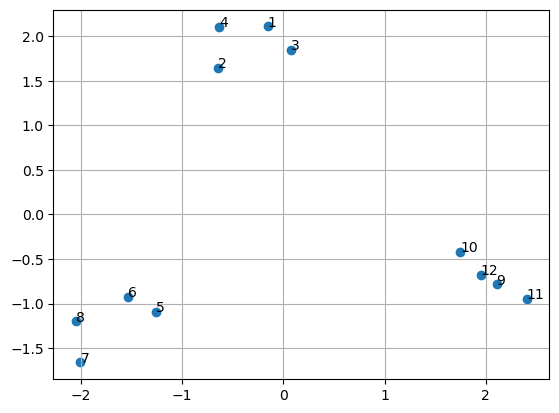

In [6]:
Xc = X - X.mean(axis=0)
U, S, Vt = np.linalg.svd(Xc , full_matrices=False)
coords = U[:, :2] * S[:2]
x_coor = coords[:,0]
y_coor = coords[:,1]
plt.scatter(x_coor, y_coor)
print("Danh sách các câu:")
for ind, label in enumerate(cau):
    plt.annotate(str(ind+1), (x_coor[ind], y_coor[ind]))
    print(f'{ind+1}: {label}')
plt.grid()
plt.show()

##### Các câu cùng chủ đề có nằm gần nhau không?
Có thể thấy, những câu cùng chủ đề nằm gần nhau.
* Cụm 1 (Câu 1 - 4) về chủ đề "Trí tuệ nhân tạo"
* Cụm 2 (Câu 5 - 8) về chủ đề "Học tập"
* Cụm 3 (Câu 9 - 12) về chủ đề "Ẩm thực tại Sài Gòn"
##### Liên hệ với eigen/PCA và “trục chính” của dữ liệu.
Eigendecomposition và SVD đều là hai phương thức để thực hiện PCA và cùng ra kết quả. Xét eigendecomposition, vì dùng ma trận hiệp phương sai (ma trận vuông $N*N$ với $N$ là số lượng từ khác nhau) nên việc thực hiện PCA dễ gây sai số liệu tốn nhiều thời gian và bộ nhớ hơn khi bộ dữ liệu lớn. Bên cạnh đó, eigendecomposition chỉ có thể sử dụng được khi ma trận đầu vào là một ma trận vuông và không phải khi nào bộ dữ liệu cũng như vậy. Còn về SVD, ta trực tiếp phân tách một ma trận dữ liệu bất kì mà không cần tính ma trận hiệp phương sai nên sẽ xử lí nhiều bộ dữ liệu nhanh hơn và ổn định hơn so với eigen. "Trục chính" của dữ liệu là ma trận Vt ($V^T$) sau khi phân tách nhằm cho thấy hướng mang nhiều thông tin nhất (mỗi hàng hoạt động tương tự một eigenvector).
